Analyse de la qualité des donnnées.
##### Objectif :  Evaluer la qualité des données du dataset de marketing
    

Importation des bibliothèques nécessaires et chargement du dataset

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from scipy.stats import chi2_contingency

In [91]:

# Chargement du dataset
df_raw=pd.read_csv("../Data/Raw/marketing_data.csv") #importation du dataset brute sous forme de dataframe
df=df_raw.copy() #copie du dataframe

In [92]:
#Vérification de la réussite du chargement
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,Spain


In [93]:
# Liste les colonnes 
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='str')

In [94]:
#Renomination des colonnes du dataset
df.rename(columns={'Education':'Niveau_Education','Year_Birth' : 'Annee_naissance','Marital_Status' : 'Statut_Marital',' Income ' : 'Revenu', 'Kidhome' : 'Nb_Enfants', 'Teenhome' : 'Nb_Ado', 'Dt_Customer': 'Date_Inscription', 'Recency':'Nbjour_Dernier_Achat','MntWines': 'Montant_Vins', 'MntFruits':'Montant_Fruits', 'MntMeatProducts':'Montant_Viandes', 'MntFishProducts':'Montant_Poissons', 'MntSweetProducts':'Montant_Sucreries','MntGoldProds':'Montant_Or', 'NumDealsPurchases':'NbAchat_Remise','NumWebPurchases':'NbAchat_SiteWeb', 'NumCatalogPurchases':'NbAchat_Catalogue','NumStorePurchases':'NbAchat_Magasin','NumWebVisitsMonth':'NbVisit_SiteWebCeMois','AcceptedCmp3':'Campagne3','AcceptedCmp4':'Campagne4', 'AcceptedCmp5':'Campagne5', 'AcceptedCmp2':'Campagne2', 'AcceptedCmp1':'Campagne1', 'Response':'Reponse','Complain':'Plaintes','Country':'Pays'}, inplace=True)


In [95]:

#Afficher les 5 premières lignes pour vérifier
print(df.head().to_string(index=False))

   ID  Annee_naissance Niveau_Education Statut_Marital  Revenu  Nb_Enfants  Nb_Ado Date_Inscription  Nbjour_Dernier_Achat  Montant_Vins  Montant_Fruits  Montant_Viandes  Montant_Poissons  Montant_Sucreries  Montant_Or  NbAchat_Remise  NbAchat_SiteWeb  NbAchat_Catalogue  NbAchat_Magasin  NbVisit_SiteWebCeMois  Campagne3  Campagne4  Campagne5  Campagne1  Campagne2  Reponse  Plaintes      Pays
 1826             1970       Graduation       Divorced 84835.0           0       0       2014-06-16                     0           189             104              379               111                189         218               1                4                  4                6                      1          0          0          0          0          0        1         0     Spain
    1             1961       Graduation         Single 57091.0           0       0       2014-06-15                     0           464               5               64                 7                  0       

Analyse et identification des incohérences et des données éronnées 

In [96]:
#présentation générale  des informations du dataset et du nombre de valeurs non manquantes par colonne
df.shape #utile pour connaitre le nombre de ligne et de colonnes du dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2240 non-null   int64  
 1   Annee_naissance        2240 non-null   int64  
 2   Niveau_Education       2240 non-null   str    
 3   Statut_Marital         2240 non-null   str    
 4   Revenu                 2216 non-null   float64
 5   Nb_Enfants             2240 non-null   int64  
 6   Nb_Ado                 2240 non-null   int64  
 7   Date_Inscription       2240 non-null   str    
 8   Nbjour_Dernier_Achat   2240 non-null   int64  
 9   Montant_Vins           2240 non-null   int64  
 10  Montant_Fruits         2240 non-null   int64  
 11  Montant_Viandes        2240 non-null   int64  
 12  Montant_Poissons       2240 non-null   int64  
 13  Montant_Sucreries      2240 non-null   int64  
 14  Montant_Or             2240 non-null   int64  
 15  NbAchat_Remise 

In [97]:
#Fouille des colonnes afin d'identifier des anomalies
for val in df.select_dtypes(exclude=["int","datetime","float"]):
    print(f"---------{val}--------")
    print(df[val].unique())
    print(df[val].value_counts())

---------Niveau_Education--------
<StringArray>
['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']
Length: 5, dtype: str
Niveau_Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
---------Statut_Marital--------
<StringArray>
['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO', 'Alone',
 'Absurd']
Length: 8, dtype: str
Statut_Marital
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64
---------Date_Inscription--------
<StringArray>
['2014-06-16', '2014-06-15', '2014-05-13', '2014-05-11', '2014-04-08',
 '2014-03-17', '2014-01-29', '2014-01-18', '2014-01-11', '2013-12-27',
 ...
 '2013-06-26', '2013-05-24', '2012-08-15', '2013-12-10', '2012-09-19',
 '2012-08-10', '2014-06-06', '2013-05-25', '2013-04-09', '2012-09-01']
Length: 663, dtype: str
Date_Inscription
2012-08-31    12
2013-02-14    11
2014-05

In [98]:
#Filtrage de la valeur YOLO 
df.iloc[df["Statut_Marital"]=="YOLO"]

,ID,Annee_naissance,Niveau_Education,Statut_Marital,Revenu,Nb_Enfants,Nb_Ado,Date_Inscription,Nbjour_Dernier_Achat,Montant_Vins,...,NbAchat_Magasin,NbVisit_SiteWebCeMois,Campagne3,Campagne4,Campagne5,Campagne1,Campagne2,Reponse,Plaintes,Pays
103,492,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,6,8,0,0,0,0,0,0,0,Canada
104,11133,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,6,8,0,0,0,0,0,1,0,India


In [99]:
#Filtrage de la valeur Absurd
df.iloc[df["Statut_Marital"]=="Absurd"]

,ID,Annee_naissance,Niveau_Education,Statut_Marital,Revenu,Nb_Enfants,Nb_Ado,Date_Inscription,Nbjour_Dernier_Achat,Montant_Vins,...,NbAchat_Magasin,NbVisit_SiteWebCeMois,Campagne3,Campagne4,Campagne5,Campagne1,Campagne2,Reponse,Plaintes,Pays
1068,4369,1957,Master,Absurd,65487.0,0,0,2014-01-10,48,240,...,6,2,0,0,0,0,0,0,0,Canada
1339,7734,1993,Graduation,Absurd,79244.0,0,0,2012-12-19,58,471,...,7,1,0,0,1,1,0,1,0,Australia


In [100]:
# Description statistique des variables catégorielles(moyenne, Q1,Q2,Q3, min, max, nombre de valeurs, ...)
df.describe(include="object")

C:\Users\Kardo BALOSSA\AppData\Local\Temp\ipykernel_12812\3800433334.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Niveau_Education,Statut_Marital,Date_Inscription,Pays
count,2240,2240,2240,2240
unique,5,8,663,8
top,Graduation,Married,2012-08-31,Spain
freq,1127,864,12,1095


In [101]:
# Description statistique des variables numériques (moyenne, Q1,Q2,Q3, min, max, nombre de valeurs, ...)
df.describe(include="int") #ou df.describe()

#df.describe(include="all") #description statistique de tous les types de données

,ID,Annee_naissance,Nb_Enfants,Nb_Ado,Nbjour_Dernier_Achat,Montant_Vins,Montant_Fruits,Montant_Viandes,Montant_Poissons,Montant_Sucreries,...,NbAchat_Catalogue,NbAchat_Magasin,NbVisit_SiteWebCeMois,Campagne3,Campagne4,Campagne5,Campagne1,Campagne2,Reponse,Plaintes
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2240 non-null   int64  
 1   Annee_naissance        2240 non-null   int64  
 2   Niveau_Education       2240 non-null   str    
 3   Statut_Marital         2240 non-null   str    
 4   Revenu                 2216 non-null   float64
 5   Nb_Enfants             2240 non-null   int64  
 6   Nb_Ado                 2240 non-null   int64  
 7   Date_Inscription       2240 non-null   str    
 8   Nbjour_Dernier_Achat   2240 non-null   int64  
 9   Montant_Vins           2240 non-null   int64  
 10  Montant_Fruits         2240 non-null   int64  
 11  Montant_Viandes        2240 non-null   int64  
 12  Montant_Poissons       2240 non-null   int64  
 13  Montant_Sucreries      2240 non-null   int64  
 14  Montant_Or             2240 non-null   int64  
 15  NbAchat_Remise 

In [103]:
df["Montant_Total"]=(
    df["Montant_Vins"]
    +df["Montant_Poissons"]
    +df["Montant_Fruits"]
    +df["Montant_Viandes"]
    +df["Montant_Sucreries"]
    +df["Montant_Or"]
)
for val in df[["Revenu","Montant_Total"]]:
    print(f"---------{val}-----------")
    print(df.groupby("Statut_Marital")[val].median())

---------Revenu-----------
Statut_Marital
Absurd      72365.5
Alone       35860.0
Divorced    52683.0
Married     51876.0
Single      48904.0
Together    51369.0
Widow       56551.0
YOLO        48432.0
Name: Revenu, dtype: float64
---------Montant_Total-----------
Statut_Marital
Absurd      1192.5
Alone         89.0
Divorced     395.0
Married      396.5
Single       361.0
Together     393.5
Widow        636.0
YOLO         424.0
Name: Montant_Total, dtype: float64


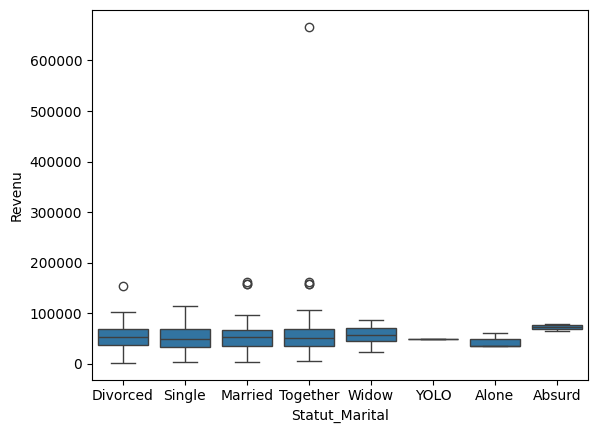

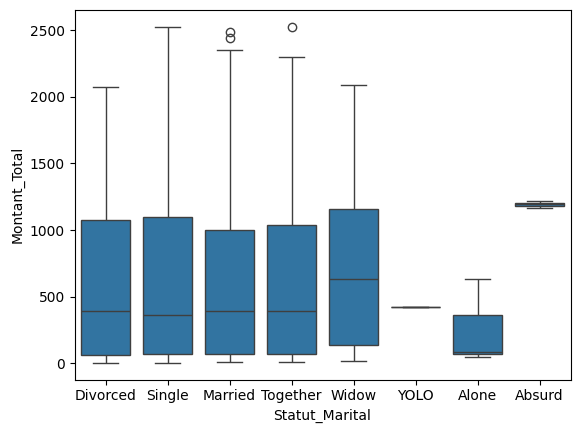

In [104]:
for val in df[["Revenu","Montant_Total"]]:
    sns.boxplot(x="Statut_Marital", y=val, data=df)
    plt.show()

Observation :
###### Nous remarquons que Date_Inscription est de type object ce qui n'est pas correcte. Nous allons donc le transformer en type de date.
###### Nous remarquons les colonnes portant sur les campagnes et réponses sont de type int. Nous allons donc les transformer en booléen
###### Nous manipulons mieux les âges que les années. Nous allons insérer la colonne de Age. Il sera calculé en tenant compte de 2014 comme année de référence car  dans le dataset, les activités se sont déroulées de 2012 à 2014,aussi les colonnes de la date d'inscription et du nombre jour effectué après le dernier acaht, nous font comprendre que les clients sont toujours actifs en 2014
###### Dans la colonne Niveau_Education nous avons remarqué Graduation qui n'est pas un niveau d'éducation. Nous devons donc le remplacer par Graduate
###### Dans la colonne Statut_Marital, nous avons d'un côté YOLO et Abusurd qui ne sont pas des statuts matrimoniaux et seront supprimés car ils sont très peu
###### De l'autre Alone et Single seront fusionnés car ils ont le même sens
###### Aussi, Married et Together seront fusionnés. En effet, nous avons étudié la similarité de Married et Together tant statistiquement(mediane par groupe des Revenu et Montant_Total) que graphiquement(boxplot)


Traitement des incohérences et données erronées

In [105]:

df['Date_Enrollement']=pd.to_datetime(df['Date_Inscription'])
df.drop('Date_Inscription', axis='columns', inplace=True) #suppression de la colonne Date_inscription

In [106]:
#Conversion de int en bool des colonnes campagnes, reponses, plaintes
campagne_type=["Campagne1","Campagne2","Campagne3","Campagne4","Campagne5","Reponse", "Plaintes"]
for val in campagne_type:
    df[val]=df[val].astype(bool)

In [107]:
#Trouvons l'âge des clients. Nous allons le faire en tenant compte de 2014
# Car les activités se sont déroulés de 2012 à 2014
from datetime import datetime
df['Age']=2014-df['Annee_naissance']

In [108]:
#Remplacement de Graduation par Graduate 
df["Niveau_Education"]=df["Niveau_Education"].replace({"Graduation":"Graduate"}, inplace=True) 

C:\Users\Kardo BALOSSA\AppData\Local\Temp\ipykernel_12812\3360695937.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Niveau_Education"]=df["Niveau_Education"].replace({"Graduation":"Graduate"}, inplace=True)


In [109]:
#Fusion de Single et Alone
df["Statut_Marital"]=df["Statut_Marital"].replace("Alone","Single")

#Fusion de Married et Together
df["Statut_Marital"]=df["Statut_Marital"].replace("Together","Married")

#Suppression des valeurs YOLO et Together
df=df[~df["Statut_Marital"].isin(["YOLO","Absurd"])]

In [110]:
df["Age"]

0       44
1       53
2       56
3       47
4       25
        ..
2235    38
2236    37
2237    38
2238    36
2239    45
Name: Age, Length: 2236, dtype: int64

In [111]:
df["Statut_Marital"].unique()

<StringArray>
['Divorced', 'Single', 'Married', 'Widow']
Length: 4, dtype: str

Analyse et identifaction des doublons

In [112]:
#nombre de lignes exactement identiques
df.duplicated().sum()

np.int64(0)

Observation: Il n'y a aucun doublon

Analyse et indentification des valeurs manquantes

In [113]:
#comptage des valeurs manquantes par colonne
df.isnull().sum()

ID                        0
Annee_naissance           0
Niveau_Education          0
Statut_Marital            0
Revenu                   24
Nb_Enfants                0
Nb_Ado                    0
Nbjour_Dernier_Achat      0
Montant_Vins              0
Montant_Fruits            0
Montant_Viandes           0
Montant_Poissons          0
Montant_Sucreries         0
Montant_Or                0
NbAchat_Remise            0
NbAchat_SiteWeb           0
NbAchat_Catalogue         0
NbAchat_Magasin           0
NbVisit_SiteWebCeMois     0
Campagne3                 0
Campagne4                 0
Campagne5                 0
Campagne1                 0
Campagne2                 0
Reponse                   0
Plaintes                  0
Pays                      0
Montant_Total             0
Date_Enrollement          0
Age                       0
dtype: int64

In [114]:
df[df["Revenu"].isna()]

,ID,Annee_naissance,Niveau_Education,Statut_Marital,Revenu,Nb_Enfants,Nb_Ado,Nbjour_Dernier_Achat,Montant_Vins,Montant_Fruits,...,Campagne4,Campagne5,Campagne1,Campagne2,Reponse,Plaintes,Pays,Montant_Total,Date_Enrollement,Age
134,8996,1957,PhD,Married,NaN,2,1,4,230,42,...,False,False,False,False,False,False,Germany,603,2012-11-19,57
262,1994,1983,Graduate,Married,NaN,1,0,11,5,5,...,False,False,False,False,False,False,USA,19,2013-11-15,31
394,3769,1972,PhD,Married,NaN,1,0,17,25,1,...,False,False,False,False,False,False,Australia,42,2014-03-02,42
449,5255,1986,Graduate,Single,NaN,1,0,19,5,1,...,False,False,False,False,False,False,Australia,637,2013-02-20,28
525,8268,1961,PhD,Married,NaN,0,1,23,352,0,...,False,False,False,False,False,False,Canada,404,2013-07-11,53
590,10629,1973,2n Cycle,Married,NaN,1,0,25,25,3,...,False,False,False,False,False,False,Germany,109,2012-09-14,41
899,10475,1970,Master,Married,NaN,0,1,39,187,5,...,False,False,False,False,False,False,USA,317,2013-04-01,44
997,9235,1957,Graduate,Single,NaN,1,1,45,7,0,...,False,False,False,False,False,False,Germany,18,2014-05-27,57
1096,4345,1964,2n Cycle,Single,NaN,1,1,49,5,1,...,False,False,False,False,False,False,Australia,21,2014-01-12,50
1185,7187,1969,Master,Married,NaN,1,1,52,375,42,...,False,False,False,False,False,False,Australia,721,2013-05-18,45


###### Nous remarquons que ces clients qui ont des revenus manquants,ont des dépenses enregistrées concernant les fruits, poissons et autres. Les valeurs manquantes ne signifient pas ces clients n'ont pas de revenu

In [115]:
#Nous devons avant tout trouver le type de valeurs manquantes(MCAR, MAR,MNAR) avant tout traitement
#Nous suspectons les revenus manquants de dépendre du niveau d'éducation et du statu matrimonial, du nombre d'enfants et de l'âge
#Procédons au test de contingence(d'indépendance) du khi-deux
#Evalution de la relation entre les valeurs manquantes et les colonnes suspectées
#Création de la table de contingence
def test_contingence(df,colonne):
    df["Revenu_Manquant"]=df["Revenu"].isna()
    table=pd.crosstab(df[colonne],df["Revenu_Manquant"])
    chi2, p, dof, expected=chi2_contingency(table) #chi2: Statistique de test; p:p-value; dof:degré de liberté; expected : Effectif théorique
    print(f"----------{colonne}------------")
    print(table)
    print(f"Statistique de khi-2:{chi2}")
    print(f"p-value: {p}")
    if p>0.05:
        print(f"Pas de relation significative avec les valeurs manquantes")
    else:
        print(f"Relattion significative avec les valeurs manquantes")

In [ ]:
# Transformons l'âge en groupe d'age (catégorie)
df["Groupe_Age"]=pd.cut(df["Age"],bins=[18,25,35,45,60,100],
labels=["18-25","25-35","35-45","45-60","60+"])

#Fusionnons le nombres d'enfants et ado
df["Total_Enfants"]=df["Nb_Enfants"] + df["Nb_Ado"]

#Transformons Total_Enfants en catégorie
df["Groupe_TotalEnfants"]=pd.cut(
    df["Total_Enfants"],
    bins=[0,1,2,3],
    labels=["0","1","2-3"],
    include_lowest=True #pour inclure la valeur la plus basse de l'intervalle car pandas par défaut l'exclut
    )

In [117]:
#Evaluation de la dépendance entre les valeurs manquantes et les variables suspectées
var=["Groupe_Age","Niveau_Education","Statut_Marital","Groupe_TotalEnfants"]
for i in var:
    test_contingence(df,i)

----------Groupe_Age------------
Revenu_Manquant  False  True 
Groupe_Age                   
18-25               87      1
25-35              382      4
35-45              748      8
45-60              726      9
60+                264      2
Statistique de khi-2:0.42586709510449217
p-value: 0.9803048319813155
Pas de relation significative avec les valeurs manquantes
----------Niveau_Education------------
Revenu_Manquant   False  True 
Niveau_Education              
2n Cycle            200      3
Basic                54      0
Graduate           1115     11
Master              364      5
PhD                 479      5
Statistique de khi-2:1.2804110240047517
p-value: 0.8646902178729666
Pas de relation significative avec les valeurs manquantes
----------Statut_Marital------------
Revenu_Manquant  False  True 
Statut_Marital               
Divorced           232      0
Married           1430     14
Single             474      9
Widow               76      1
Statistique de khi-2:5.53952963

Interprétation :
###### Le test de contingence indique qu'il existe  relation entre les revenus manquants et la variables Groupe_TotalEnfants. De ce fait, les variables manquantes  sont de type MAR.

Imputation et traitement des valeurs manquantes
###### Nous devons choisir entre l'imputation par la moyenne et celle par la médiane. Il faut donc étudier la normalité de la distribution de la série de données afin de faire le choix

In [118]:
#Vérifions la nature de la distribution de la série de données(Revenu)
#Vérification de la normalisattion des données

def test_shapiro(df):
    for i in df.select_dtypes(include='number').columns:
        stat_test, p=shapiro(df[i])
        print(i)
        if p>0.05 :
            print("Les données suivent la loi normale")
        else:
            print("Les données ne suivent par la loi normale")  
test_shapiro(df)


ID
Les données ne suivent par la loi normale
Annee_naissance
Les données ne suivent par la loi normale
Revenu
Les données ne suivent par la loi normale
Nb_Enfants
Les données ne suivent par la loi normale
Nb_Ado
Les données ne suivent par la loi normale
Nbjour_Dernier_Achat
Les données ne suivent par la loi normale
Montant_Vins
Les données ne suivent par la loi normale
Montant_Fruits
Les données ne suivent par la loi normale
Montant_Viandes
Les données ne suivent par la loi normale
Montant_Poissons
Les données ne suivent par la loi normale
Montant_Sucreries
Les données ne suivent par la loi normale
Montant_Or
Les données ne suivent par la loi normale
NbAchat_Remise
Les données ne suivent par la loi normale
NbAchat_SiteWeb
Les données ne suivent par la loi normale
NbAchat_Catalogue
Les données ne suivent par la loi normale
NbAchat_Magasin
Les données ne suivent par la loi normale
NbVisit_SiteWebCeMois
Les données ne suivent par la loi normale
Montant_Total
Les données ne suivent par la 

Observation:
###### Les données de la colonne Revenu ne suivent pas la loi normale. Nous optons donc pour l'imputation par la médiane. Nous allons faire une imputation conditionnelle. C'est-à-dire, en tenant compte des différents groupes des revenus des clients par Groupe_TotalEnfants nous allons remplacer chaque valeur manquante par la médiane de son groupe correspondant

In [119]:
#Imputation conditionnelle
df["Revenu"]=df["Revenu"].fillna(df.groupby("Groupe_TotalEnfants")["Revenu"].transform("median"))

In [120]:
df["Revenu"].count()

np.int64(2236)

Conclusion : Les valeurs manquantes sont  traitées

Analyse et identification des valeurs aberrantes

###### Nous connaissons déjà que les donnéees ne suivent paar la loi normale. Dans ce cas, nous allons procéder par une analyse graphique et  une analyse statistique basée sur la méthode de l'IQR pour identifier et analyser les valeurs aberrantes. Si les données suivaient la loi normale, nous aurions une analyse statistique basée sur la méthode du Z-score

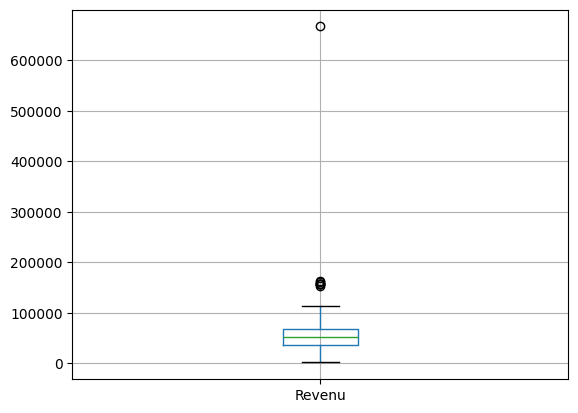

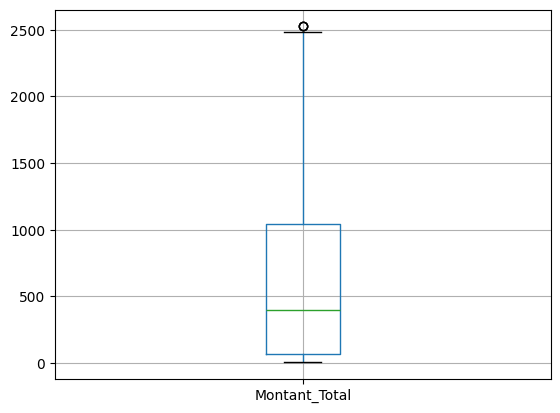

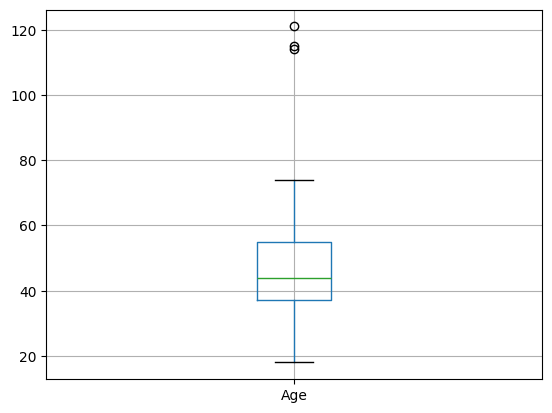

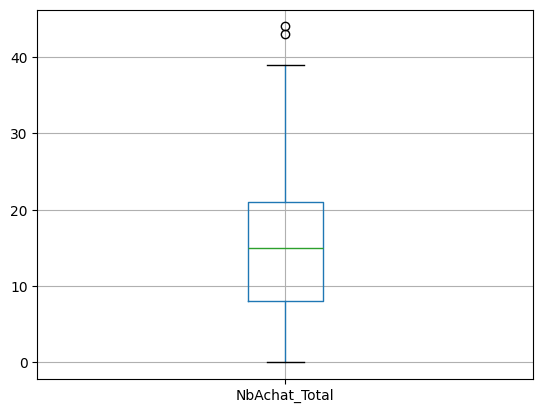

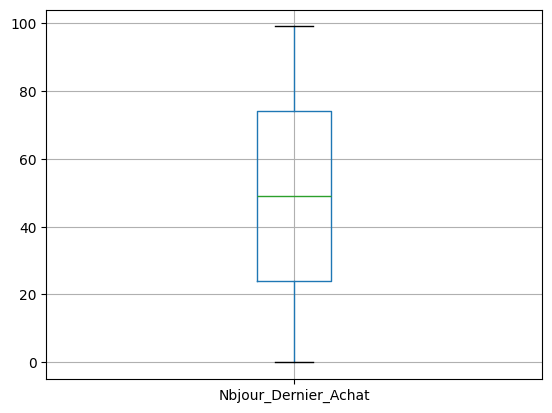

In [121]:
#Analyse graphique : Cherchons les outliers
#Fusionnons les nombres d'achats
df["NbAchat_Total"]=(
    df["NbAchat_Catalogue"]
    +df["NbAchat_Remise"]
    +df["NbAchat_SiteWeb"]
    +df["NbAchat_Magasin"]
)
for val in df[["Revenu","Montant_Total","Age", "NbAchat_Total", "Nbjour_Dernier_Achat"]]:
    df.boxplot(val)
    plt.show()

Note : 
###### Regrouper en Montant_Total et NbAchat_Total permet d'éviter de considérer comme aberrant une préférence de produit ou de canal d'achat

In [122]:

#Analyse statistique: Détection des valeurs aberrantes avec l'approche de l'IQR
def valeur_aberrante(df,colonne):
    if colonne in df.select_dtypes(include="number").columns:
        valeur=df[colonne].sort_values(ascending=True)
        q1=valeur.quantile(0.25)        #ou q1=np.percentile(valeur, 25)
        q2=valeur.quantile(0.50)        #ou q2=np.percentile(valeur,50)
        q3=valeur.quantile(0.75)        #ou q3=np.percentile(valeur,75)
        iqr=q3-q1
        born_inf=q1-1.5*iqr
        born_sup=q3+1.5*iqr
        aberrantes=valeur[(valeur < born_inf) | (valeur> born_sup) ]
        print(f"----- {colonne} -----")
        print(f"Minimum:{df[colonne].min()}")
        print(f"Maximum:{df[colonne].max()}")
        print(f"Q1 = {q1}, Q2 = {q2}, Q3 = {q3}")
        print(f"Borne inférieure = {born_inf}, Borne supérieure = {born_sup}")
        if aberrantes.empty:
            print("Aucune valeur aberrante détectée.")
        else:
            print(f"le nombre de valeurs aberrantes est :{aberrantes.count()}\n")
            print("Valeurs aberrantes détectées :")
            print(aberrantes.to_string(index=False))
        print("\n")
    else :
        print(f"Les valeurs aberrantes n'existent pas pour des variables catégorielles")

In [123]:
#Appel de la fonction en considérant les variables suspectées
for val in df[["Revenu","Montant_Total","Age", "NbAchat_Total", "Nbjour_Dernier_Achat"]]:
    valeur_aberrante(df,val)

----- Revenu -----
Minimum:1730.0
Maximum:666666.0
Q1 = 35502.5, Q2 = 51498.5, Q3 = 68289.75
Borne inférieure = -13678.375, Borne supérieure = 117470.625
le nombre de valeurs aberrantes est :8

Valeurs aberrantes détectées :
153924.0
156924.0
157146.0
157243.0
157733.0
160803.0
162397.0
666666.0


----- Montant_Total -----
Minimum:5
Maximum:2525
Q1 = 68.0, Q2 = 395.5, Q3 = 1044.25
Borne inférieure = -1396.375, Borne supérieure = 2508.625
le nombre de valeurs aberrantes est :3

Valeurs aberrantes détectées :
2524
2525
2525


----- Age -----
Minimum:18
Maximum:121
Q1 = 37.0, Q2 = 44.0, Q3 = 55.0
Borne inférieure = 10.0, Borne supérieure = 82.0
le nombre de valeurs aberrantes est :3

Valeurs aberrantes détectées :
114
115
121


----- NbAchat_Total -----
Minimum:0
Maximum:44
Q1 = 8.0, Q2 = 15.0, Q3 = 21.0
Borne inférieure = -11.5, Borne supérieure = 40.5
le nombre de valeurs aberrantes est :2

Valeurs aberrantes détectées :
43
44


----- Nbjour_Dernier_Achat -----
Minimum:0
Maximum:99
Q1 =

In [124]:
df.iloc[df["Revenu"]>150000]

,ID,Annee_naissance,Niveau_Education,Statut_Marital,Revenu,Nb_Enfants,Nb_Ado,Nbjour_Dernier_Achat,Montant_Vins,Montant_Fruits,...,Plaintes,Pays,Montant_Total,Date_Enrollement,Age,Groupe_Age,Total_Enfants,Groupe_TotalEnfants,Revenu_Manquant,NbAchat_Total
325,4931,1977,Graduate,Married,157146.0,0,0,13,1,0,...,False,Saudi Arabia,1730,2013-04-29,37,35-45,0,0,False,28
497,1501,1982,PhD,Married,160803.0,0,0,21,55,16,...,False,USA,1717,2012-08-04,32,25-35,0,0,False,44
527,9432,1977,Graduate,Married,666666.0,1,0,23,9,14,...,False,Saudi Arabia,62,2013-06-02,37,35-45,1,0,False,11
731,1503,1976,PhD,Married,162397.0,1,1,31,85,1,...,False,Spain,107,2013-06-03,38,35-45,2,1,False,1
853,5336,1971,Master,Married,157733.0,1,0,37,39,1,...,False,Spain,59,2013-06-04,43,35-45,1,0,False,2
1826,5555,1975,Graduate,Divorced,153924.0,0,0,81,1,1,...,False,Spain,6,2014-02-07,39,35-45,0,0,False,0
1925,11181,1949,PhD,Married,156924.0,0,0,85,2,1,...,False,Canada,8,2013-08-29,65,60+,0,0,False,0
2204,8475,1973,PhD,Married,157243.0,0,1,98,20,2,...,False,India,1608,2014-03-01,41,35-45,1,0,False,37


In [125]:
df.iloc[df["Montant_Total"]>2000]

,ID,Annee_naissance,Niveau_Education,Statut_Marital,Revenu,Nb_Enfants,Nb_Ado,Nbjour_Dernier_Achat,Montant_Vins,Montant_Fruits,...,Plaintes,Pays,Montant_Total,Date_Enrollement,Age,Groupe_Age,Total_Enfants,Groupe_TotalEnfants,Revenu_Manquant,NbAchat_Total
70,1772,1975,PhD,Married,79174.0,0,0,2,1074,37,...,False,Canada,2043,2013-01-11,39,35-45,0,0,False,19
77,7919,1976,PhD,Married,72335.0,0,0,2,1285,105,...,False,Spain,2092,2012-08-13,38,35-45,0,0,False,23
283,3403,1958,PhD,Married,78952.0,0,1,11,1170,19,...,False,Spain,2092,2012-09-24,56,45-60,1,0,False,21
335,3698,1983,Graduate,Married,78687.0,0,0,13,817,185,...,False,Spain,2130,2012-08-09,31,25-35,0,0,False,19
376,10133,1970,Graduate,Single,93790.0,0,0,16,1302,68,...,False,Canada,2349,2014-02-12,44,35-45,0,0,False,25
385,6072,1970,Master,Single,75345.0,0,0,16,918,57,...,False,Spain,2087,2013-02-02,44,35-45,0,0,False,20
470,3690,1986,Master,Married,80141.0,0,0,20,1184,102,...,False,Spain,2091,2013-01-11,28,25-35,0,0,False,22
517,4248,1960,Master,Single,98777.0,0,0,23,1000,19,...,False,Spain,2008,2014-02-17,54,45-60,0,0,False,19
518,7451,1960,Master,Single,98777.0,0,0,23,1000,19,...,False,Spain,2008,2014-02-17,54,45-60,0,0,False,19
588,7627,1975,Master,Married,92163.0,0,0,25,817,183,...,False,Spain,2086,2012-12-12,39,35-45,0,0,False,21


In [126]:
df.iloc[df["NbAchat_Total"]>40]

,ID,Annee_naissance,Niveau_Education,Statut_Marital,Revenu,Nb_Enfants,Nb_Ado,Nbjour_Dernier_Achat,Montant_Vins,Montant_Fruits,...,Plaintes,Pays,Montant_Total,Date_Enrollement,Age,Groupe_Age,Total_Enfants,Groupe_TotalEnfants,Revenu_Manquant,NbAchat_Total
497,1501,1982,PhD,Married,160803.0,0,0,21,55,16,...,False,USA,1717,2012-08-04,32,25-35,0,0,False,44
961,5376,1979,Graduate,Married,2447.0,1,0,42,1,1,...,False,USA,1730,2013-01-06,35,25-35,1,0,False,43


In [127]:
df.iloc[df["Age"]>100]

,ID,Annee_naissance,Niveau_Education,Statut_Marital,Revenu,Nb_Enfants,Nb_Ado,Nbjour_Dernier_Achat,Montant_Vins,Montant_Fruits,...,Plaintes,Pays,Montant_Total,Date_Enrollement,Age,Groupe_Age,Total_Enfants,Groupe_TotalEnfants,Revenu_Manquant,NbAchat_Total
513,11004,1893,2n Cycle,Single,60182.0,0,1,23,8,0,...,False,Saudi Arabia,22,2014-05-17,121,NaN,1,0,False,4
827,1150,1899,PhD,Married,83532.0,0,0,36,755,144,...,False,Spain,1853,2013-09-26,115,NaN,0,0,False,15
2233,7829,1900,2n Cycle,Divorced,36640.0,1,0,99,15,6,...,True,India,65,2013-09-26,114,NaN,1,0,False,6


In [128]:
#Vérification de la relation entre Revenu et Montant_Total
df[["Revenu","Montant_Total"]].corr() #il existe une relation positive mais pas entre ces variables qui ne sont pas parfaites

,Revenu,Montant_Total
Revenu,1.000000,0.664762
Montant_Total,0.664762,1.000000


In [129]:
#Suppression de la valeur 666666
df=df[~(df["Revenu"]>250000)]

#Suppression de l'âge
df=df[~(df["Age"]>100)]

Conclusion:
###### Il sied de souligner que toutes les valeurs aberrantes sont pas des erreurs. C'est le cas de des colonnes Montant_Total et NbAchat_Total qui présentent des outliers très proches de la borne supérieure. Elles peuvent être expliquer par le fait que certains clients ont un pouvoir d'achat élevé

###### L'analyse tant statistque que graphique de la colonne Revenu nous permis de constater des valeurs aberrantes assez proches de la borne supérieure et une très éloignéé(extrême) qui est 666666. Nous l'avons donc supprimé car  sa proportion est très faible. 
###### Aussi, d'autres valeurs aberrantes ont été acceptées car elles se rapprochent de la tendance des des revenus des clients

###### L'analyse tant statistique que graphique de la colonne Age nous permis de connstater trois valeurs aberrantes qui sont 114, 115 et 121ans. Ces valeurs sont loin d'être plausibles et tenant compte de leur faible proportion sur l'âge des clients nous les avons supprimé

Fin de la phase de nettoyage et export du dataset en fichier csv

In [132]:
df.to_csv("C:/Users/Kardo BALOSSA/Data_Analyis_Projects/marketing-data-analyst-project/Data/Clean/dataset_cleaned.csv",index=False)